Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv
Rows and Columns:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.

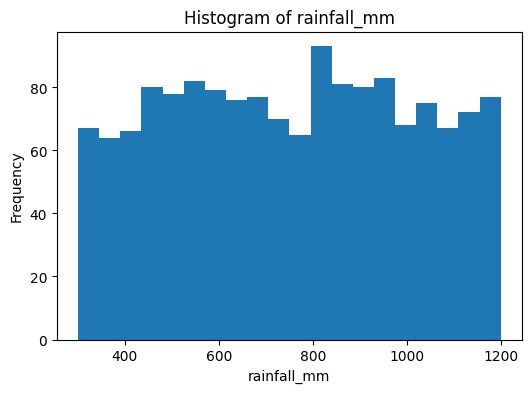

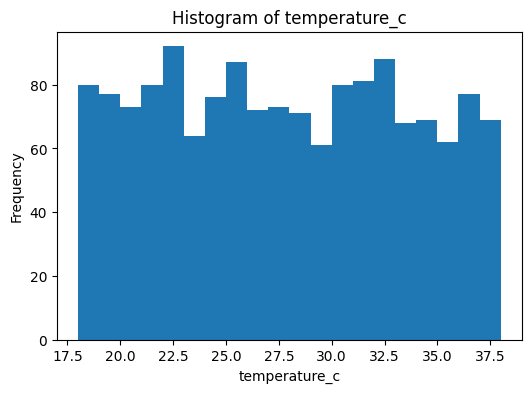

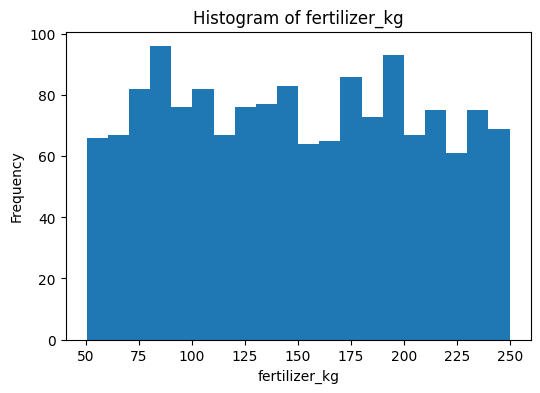

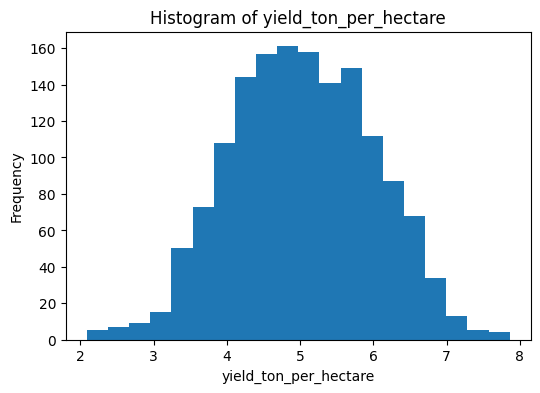


Crop Type Frequency:
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


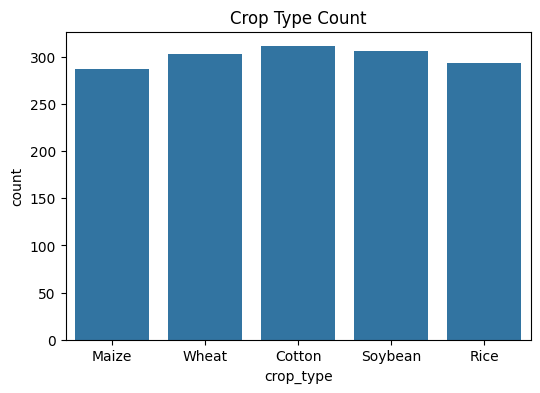


Most Frequent Crop:
Cotton

Soil Type Frequency:
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


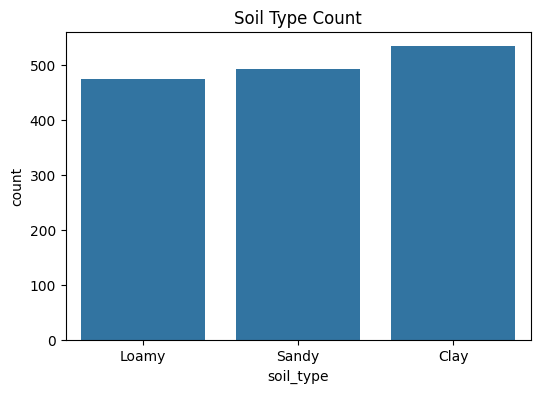


Most Common Soil Type:
Clay


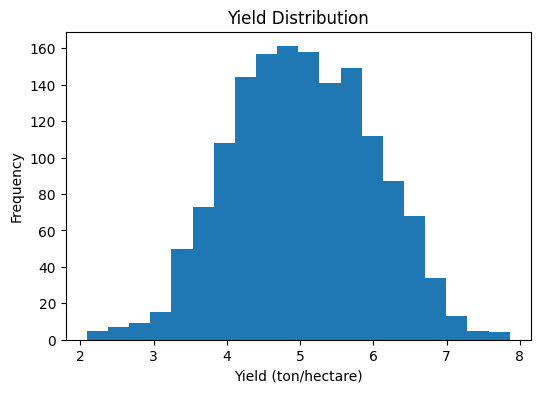

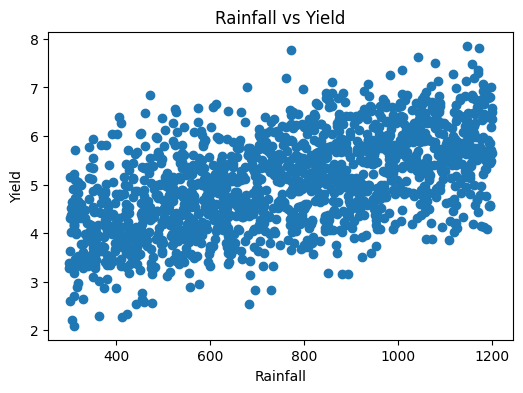

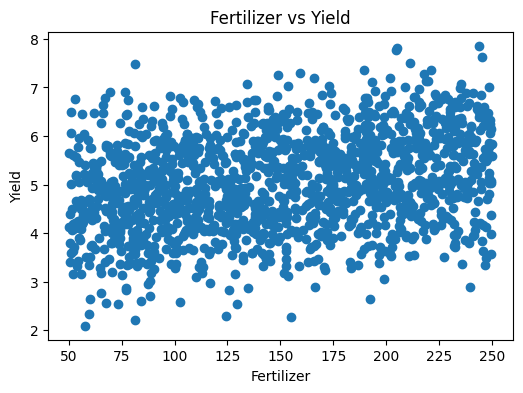


Correlation Matrix:
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

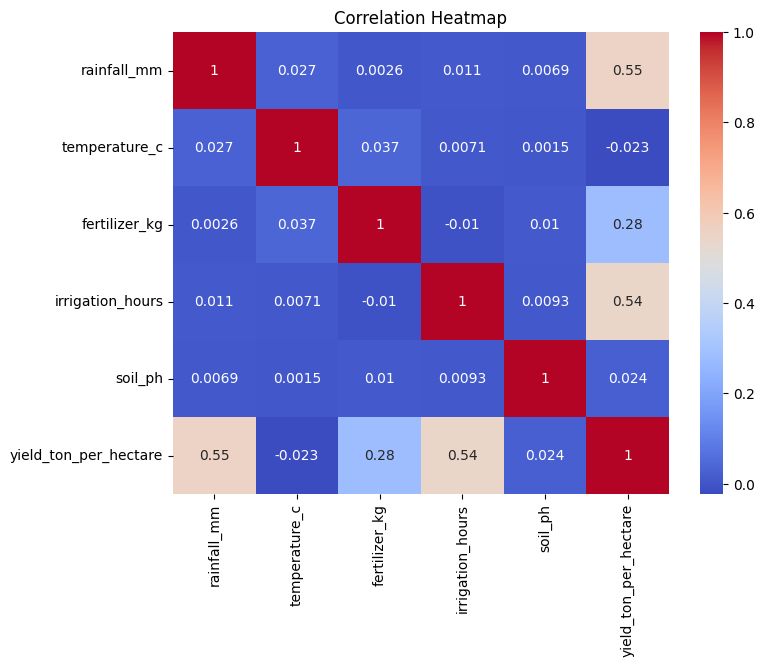


Top 3 Features Correlated With Yield:
rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Crop:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Highest Yield Crop:
Rice

Highest Yield Soil:
Loamy

Categorical Columns:
['crop_type', 'soil_type']

First 5 Rows After Encoding:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.

In [1]:
# ==========================================================
# AGRICULTURAL YIELD DATASET - COMPLETE SOLUTION (Q1-Q14)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# ----------------------------------------------------------
# LOAD DATASET
# ----------------------------------------------------------
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("agriculture_yield_dataset.csv")

# ==========================================================
# Q1. DATASET OVERVIEW
# ==========================================================

print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))


# ==========================================================
# Q2. DATA TYPES AND MISSING VALUES
# ==========================================================

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

missing_cols = df.columns[df.isnull().sum() > 0]
print("\nColumns with Missing Values:")
print(missing_cols.tolist())


# ==========================================================
# Q3. DESCRIPTIVE STATISTICS
# ==========================================================

stats = df.describe()

print("\nSummary Statistics:")
print(stats)

print("\nFeature with Highest Mean:")
print(stats.loc["mean"].idxmax())

print("\nFeature with Highest Standard Deviation:")
print(stats.loc["std"].idxmax())


# ==========================================================
# Q4. DISTRIBUTION ANALYSIS
# ==========================================================

columns = [
    "rainfall_mm",
    "temperature_c",
    "fertilizer_kg",
    "yield_ton_per_hectare"
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


# ==========================================================
# Q5. CROP TYPE ANALYSIS
# ==========================================================

print("\nCrop Type Frequency:")
print(df["crop_type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="crop_type", data=df)
plt.title("Crop Type Count")
plt.show()

print("\nMost Frequent Crop:")
print(df["crop_type"].value_counts().idxmax())


# ==========================================================
# Q6. SOIL TYPE ANALYSIS
# ==========================================================

print("\nSoil Type Frequency:")
print(df["soil_type"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="soil_type", data=df)
plt.title("Soil Type Count")
plt.show()

print("\nMost Common Soil Type:")
print(df["soil_type"].value_counts().idxmax())


# ==========================================================
# Q7. YIELD DISTRIBUTION
# ==========================================================

plt.figure(figsize=(6,4))
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield (ton/hectare)")
plt.ylabel("Frequency")
plt.show()


# ==========================================================
# Q8. SCATTER PLOT ANALYSIS
# ==========================================================

plt.figure(figsize=(6,4))
plt.scatter(
    df["rainfall_mm"],
    df["yield_ton_per_hectare"]
)
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(
    df["fertilizer_kg"],
    df["yield_ton_per_hectare"]
)
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()


# ==========================================================
# Q9. CORRELATION ANALYSIS
# ==========================================================

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

yield_corr = corr_matrix["yield_ton_per_hectare"]\
                .drop("yield_ton_per_hectare")\
                .sort_values(ascending=False)

print("\nTop 3 Features Correlated With Yield:")
print(yield_corr.head(3))


# ==========================================================
# Q10. GROUP BASED ANALYSIS
# ==========================================================

crop_yield = df.groupby("crop_type")[
    "yield_ton_per_hectare"
].mean()

soil_yield = df.groupby("soil_type")[
    "yield_ton_per_hectare"
].mean()

print("\nAverage Yield by Crop:")
print(crop_yield)

print("\nAverage Yield by Soil:")
print(soil_yield)

print("\nHighest Yield Crop:")
print(crop_yield.idxmax())

print("\nHighest Yield Soil:")
print(soil_yield.idxmax())


# ==========================================================
# Q11. FEATURE ENCODING
# ==========================================================

categorical_cols = df.select_dtypes(
    include="object"
).columns

print("\nCategorical Columns:")
print(categorical_cols.tolist())

encoded_df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nFirst 5 Rows After Encoding:")
print(encoded_df.head())


# ==========================================================
# Q12. FEATURE SELECTION
# ==========================================================

target = "yield_ton_per_hectare"

X = encoded_df.drop(target, axis=1)
y = encoded_df[target]

print("\nTarget Variable:")
print(target)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)


# ==========================================================
# Q13. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)


# ==========================================================
# Q14. LINEAR REGRESSION MODEL
# ==========================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nIntercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nCoefficients:")
print(coef_df)

highest_positive = coef_df.loc[
    coef_df["Coefficient"].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_positive)